In [6]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


Porosity: 0.3323


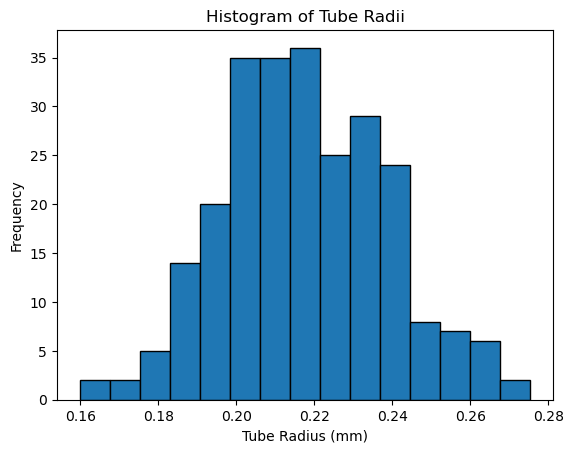

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel file
file_path = 'Homework#6 TubeRadii.xlsx'
data = pd.read_excel(file_path, header=None)  # No header in the file

# Assuming the radii data is in the first column
radii = data[0].values  # Access the first column using index 0

# Constants
L = 700  # mm
R = 6    # mm

# Calculate pore volume
V_pore = np.sum(np.pi * radii**2 * L)

# Calculate bulk volume
V_bulk = np.pi * R**2 * L

# Calculate porosity
porosity = V_pore / V_bulk

print(f"Porosity: {porosity:.4f}")

# Generate histogram
plt.hist(radii, bins=15, edgecolor='black')
plt.xlabel('Tube Radius (mm)')
plt.ylabel('Frequency')
plt.title('Histogram of Tube Radii')
plt.show()

Interstitial Velocity: 22.1575 mm/s


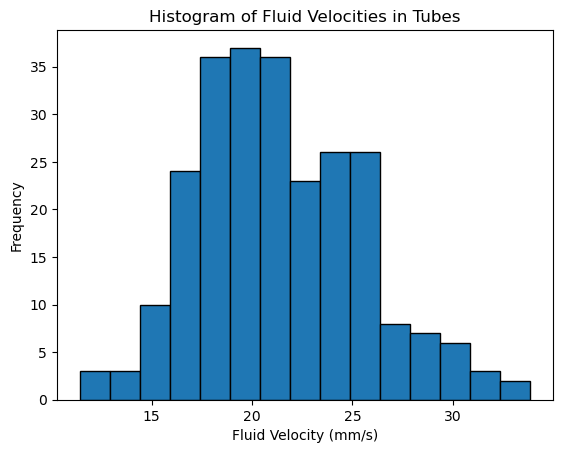

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants
L = 700  # mm
R = 6    # mm
mu = 1   # mPa·s (1 mPa·s = 1e-3 Pa·s)
delta_P = 2.5e6# Pa (2.5 kPa = 2500 Pa)

# Load the Excel file
file_path = 'Homework#6 TubeRadii.xlsx'
data = pd.read_excel(file_path, header=None)  # No header in the file

# Assuming the radii data is in the first column
radii = data[0].values  # Access the first column using index 0

# Calculate velocities in each tube
v_i = (radii**2) / (8 * mu * L) * delta_P  # in mm/s

# Calculate total volumetric flow rate Q
Q = np.sum(np.pi * radii**2 * v_i)  # in mm³/s

# Calculate porosity (assuming you have already calculated it)
phi = 0.3323  # Replace with your calculated porosity value

# Calculate interstitial velocity
v = Q / (phi * np.pi * R**2)  # in mm/s

print(f"Interstitial Velocity: {v:.4f} mm/s")

# Generate histogram of velocities
plt.hist(v_i, bins=15, edgecolor='black')
plt.xlabel('Fluid Velocity (mm/s)')
plt.ylabel('Frequency')
plt.title('Histogram of Fluid Velocities in Tubes')
plt.show()

Breakthrough Time: 20667.35 seconds


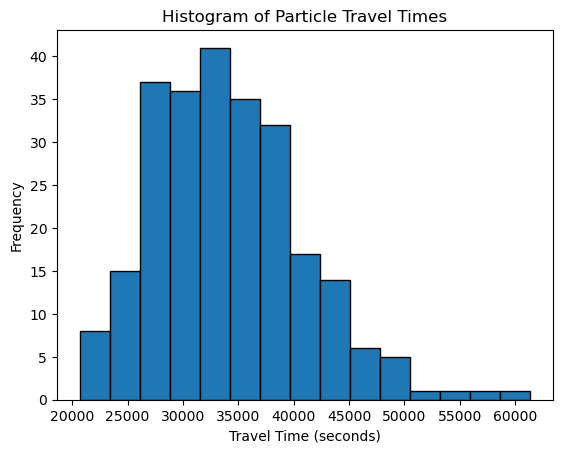

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants
L = 700  # mm
mu = 1   # mPa·s
delta_P = 2500  # Pa (2.5 kPa)

# Load radii data from Excel
file_path = 'Homework#6 TubeRadii.xlsx'
data = pd.read_excel(file_path, header=None)
radii = data[0].values  # in mm

# Calculate travel times (seconds)
t_i = (8 * mu * L**2) / (radii**2 * delta_P)

# Breakthrough time (minimum t_i)
t_breakthrough = np.min(t_i)

print(f"Breakthrough Time: {t_breakthrough:.2f} seconds")

# Generate histogram
plt.hist(t_i, bins=15, edgecolor='black')
plt.xlabel('Travel Time (seconds)')
plt.ylabel('Frequency')
plt.title('Histogram of Particle Travel Times')
plt.show()

Breakthrough Time: 10333.67 seconds


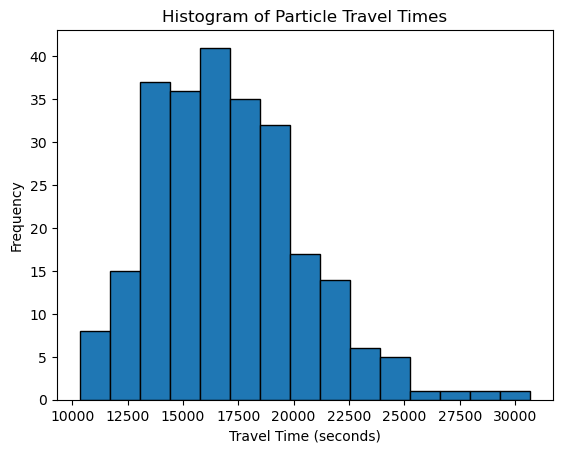

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants
L = 700  # mm
mu = 1   # mPa·s
delta_P_N = 5e3  # Pa (2.5 kPa)

# Load radii data from Excel
file_path = 'Homework#6 TubeRadii.xlsx'
data = pd.read_excel(file_path, header=None)
radii = data[0].values  # in mm

# Calculate travel times (seconds)
t_i_N = (8 * mu * L**2) / (radii**2 * delta_P_N)

# Breakthrough time (minimum t_i)
t_breakthrough = np.min(t_i)

print(f"Breakthrough Time: {t_breakthrough:.2f} seconds")

# Generate histogram
plt.hist(t_i, bins=15, edgecolor='black')
plt.xlabel('Travel Time (seconds)')
plt.ylabel('Frequency')
plt.title('Histogram of Particle Travel Times')
plt.show()

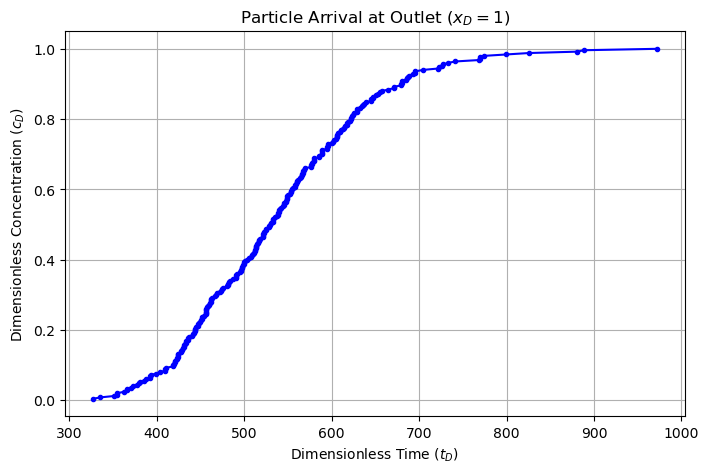

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
v = 22.16  # mm/s (interstitial velocity from part b)
L = 700    # mm

# Assume t_i is already calculated from part (a)
t_i_N = np.sort(t_i_N)  # Sort travel times in ascending order

# Calculate t_D and c_D
t_D_N = (v * t_i_N) / L
c_D_N = np.arange(1, 251) / 250  # c_D = [1/250, 2/250, ..., 1]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(t_D, c_D, marker='o', markersize=3, linestyle='-', color='b')
plt.xlabel('Dimensionless Time ($t_D$)')
plt.ylabel('Dimensionless Concentration ($c_D$)')
plt.title('Particle Arrival at Outlet ($x_D = 1$)')
plt.grid(True)
plt.show()

Interstitial Velocity (v): 44.32 mm/s


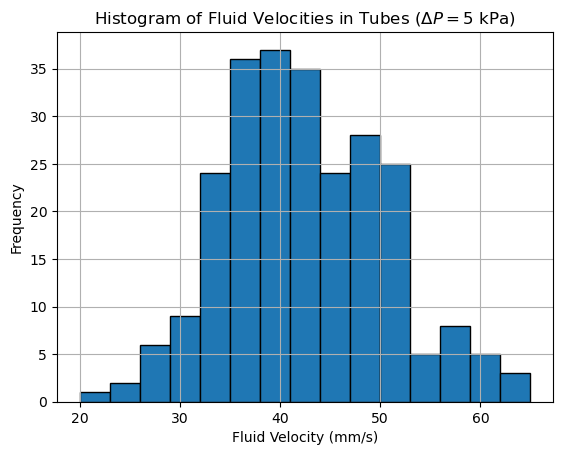

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants
L = 700       # mm
mu = 1e-3     # Pa·s (1 mPa·s)
delta_P = 5e3 # Pa (5 kPa)
R = 6         # mm
phi = 0.3323     # Replace with your porosity value

# Load radii data from Excel
file_path = 'Homework#6 TubeRadii.xlsx'
data = pd.read_excel(file_path, header=None)
radii = data[0].values  # in mm

# Calculate velocities (mm/s)
v_i = (radii**2) / (8 * mu * L) * delta_P  # Hagen-Poiseuille equation

# Calculate total flow rate Q (mm³/s)
Q = np.sum(np.pi * radii**2 * v_i)

# Calculate interstitial velocity (mm/s)
v = Q / (phi * np.pi * R**2)

print(f"Interstitial Velocity (v): {v:.2f} mm/s")

# Generate histogram of v_i
plt.hist(v_i, bins=15, edgecolor='black', range=(20, 65))
plt.xlabel('Fluid Velocity (mm/s)')
plt.ylabel('Frequency')
plt.title(r'Histogram of Fluid Velocities in Tubes ($\Delta P = 5$ kPa)')  # Fixed: Added 'r' for raw string
plt.grid(True)
plt.show()

Péclet Number (N_Pe): 45.06
Dispersion Coefficient (D): 688.52 mm²/s


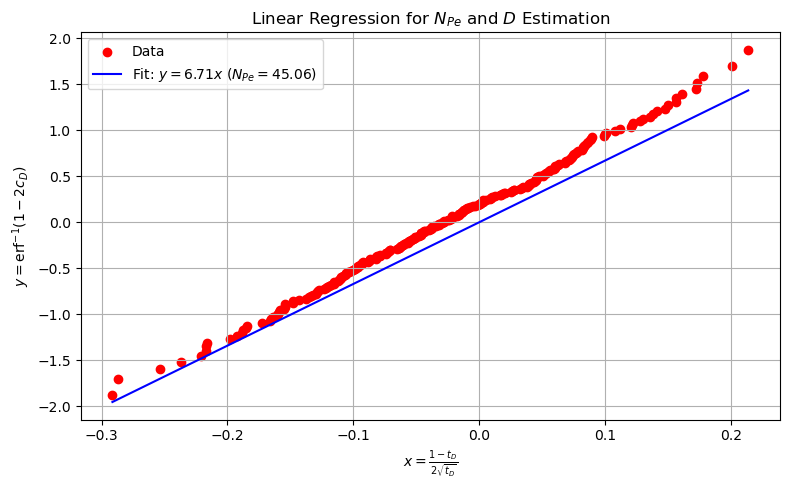

In [43]:
import pandas as pd
import numpy as np
from scipy.special import erfinv
import matplotlib.pyplot as plt

# Load data
file_path = 'Homework#6 TubeRadii.xlsx'
df = pd.read_excel(file_path, header=None)
df.columns = ['Radius_mm']

# Constants
L_mm = 700
delta_P_Pa = 5 * 1000  # 5 kPa → Pa
mu_Pa_s = 1e-3  # 1 mPa·s → Pa·s
R_bulk_mm = 6

# Convert units
df['Radius_m'] = df['Radius_mm'] / 1000
L_m = L_mm / 1000

# Calculate velocities (m/s) and travel times (s)
df['Velocity_m_per_s'] = (df['Radius_m']**2 * delta_P_Pa) / (8 * mu_Pa_s * L_m)
df['TravelTime_s'] = L_m / df['Velocity_m_per_s']  # Corrected: L_m / v_i

# Sort by travel time and compute c_D
df_sorted = df.sort_values(by='TravelTime_s').reset_index(drop=True)
df_sorted['cD'] = (df_sorted.index + 1) / 250  # c_D = n_arrive / 250

# Calculate porosity and interstitial velocity
bulk_area_mm2 = np.pi * R_bulk_mm**2
pore_volume_mm3 = np.sum(np.pi * df_sorted['Radius_mm']**2 * L_mm)
porosity = pore_volume_mm3 / (bulk_area_mm2 * L_mm)
Q_total_mm3_per_s = np.sum(np.pi * df_sorted['Radius_mm']**2 * df_sorted['Velocity_m_per_s'] * 1000)
u_interstitial_mm_per_s = Q_total_mm3_per_s / (bulk_area_mm2 * porosity)

# Dimensionless time t_D
df_sorted['tD'] = u_interstitial_mm_per_s * df_sorted['TravelTime_s'] / L_mm

# Prepare for regression: exclude c_D = 1
df_fit = df_sorted[df_sorted['cD'] < 1].copy()
df_fit['x'] = (1 - df_fit['tD']) / (2 * np.sqrt(df_fit['tD']))
df_fit['y'] = erfinv(1 - 2 * df_fit['cD'])

# Linear regression (y = slope * x)
x = df_fit['x'].values.reshape(-1, 1)
y = df_fit['y'].values
slope, _, _, _ = np.linalg.lstsq(x, y, rcond=None)

# Compute N_Pe and D
N_Pe = slope[0]**2
D_mm2_per_s = (u_interstitial_mm_per_s * L_mm) / N_Pe

print(f"Péclet Number (N_Pe): {N_Pe:.2f}")
print(f"Dispersion Coefficient (D): {D_mm2_per_s:.2f} mm²/s")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_fit['x'], df_fit['y'], color='red', label='Data')
plt.plot(x, slope * x, color='blue', label=f'Fit: $y = {slope[0]:.2f}x$ ($N_{{Pe}} = {N_Pe:.2f}$)')
plt.xlabel('$x = \\frac{1 - t_D}{2 \\sqrt{t_D}}$')
plt.ylabel('$y = \\text{erf}^{-1}(1 - 2 c_D)$')
plt.title('Linear Regression for $N_{Pe}$ and $D$ Estimation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Péclet Number (N_Pe): 45.06
Dispersion Coefficient (D): 344.26 mm²/s


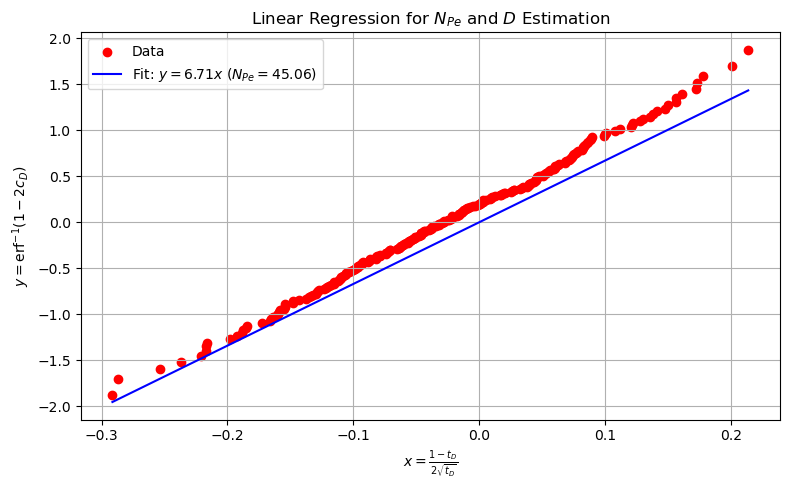

In [45]:
import pandas as pd
import numpy as np
from scipy.special import erfinv
import matplotlib.pyplot as plt

# Load data
file_path = 'Homework#6 TubeRadii.xlsx'
df = pd.read_excel(file_path, header=None)
df.columns = ['Radius_mm']

# Constants
L_mm = 700
delta_P_Pa = 2.5 * 1000  # 5 kPa → Pa
mu_Pa_s = 1e-3  # 1 mPa·s → Pa·s
R_bulk_mm = 6

# Convert units
df['Radius_m'] = df['Radius_mm'] / 1000
L_m = L_mm / 1000

# Calculate velocities (m/s) and travel times (s)
df['Velocity_m_per_s'] = (df['Radius_m']**2 * delta_P_Pa) / (8 * mu_Pa_s * L_m)
df['TravelTime_s'] = L_m / df['Velocity_m_per_s']  # Corrected: L_m / v_i

# Sort by travel time and compute c_D
df_sorted = df.sort_values(by='TravelTime_s').reset_index(drop=True)
df_sorted['cD'] = (df_sorted.index + 1) / 250  # c_D = n_arrive / 250

# Calculate porosity and interstitial velocity
bulk_area_mm2 = np.pi * R_bulk_mm**2
pore_volume_mm3 = np.sum(np.pi * df_sorted['Radius_mm']**2 * L_mm)
porosity = pore_volume_mm3 / (bulk_area_mm2 * L_mm)
Q_total_mm3_per_s = np.sum(np.pi * df_sorted['Radius_mm']**2 * df_sorted['Velocity_m_per_s'] * 1000)
u_interstitial_mm_per_s = Q_total_mm3_per_s / (bulk_area_mm2 * porosity)

# Dimensionless time t_D
df_sorted['tD'] = u_interstitial_mm_per_s * df_sorted['TravelTime_s'] / L_mm

# Prepare for regression: exclude c_D = 1
df_fit = df_sorted[df_sorted['cD'] < 1].copy()
df_fit['x'] = (1 - df_fit['tD']) / (2 * np.sqrt(df_fit['tD']))
df_fit['y'] = erfinv(1 - 2 * df_fit['cD'])

# Linear regression (y = slope * x)
x = df_fit['x'].values.reshape(-1, 1)
y = df_fit['y'].values
slope, _, _, _ = np.linalg.lstsq(x, y, rcond=None)

# Compute N_Pe and D
N_Pe = slope[0]**2
D_mm2_per_s = (u_interstitial_mm_per_s * L_mm) / N_Pe

print(f"Péclet Number (N_Pe): {N_Pe:.2f}")
print(f"Dispersion Coefficient (D): {D_mm2_per_s:.2f} mm²/s")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_fit['x'], df_fit['y'], color='red', label='Data')
plt.plot(x, slope * x, color='blue', label=f'Fit: $y = {slope[0]:.2f}x$ ($N_{{Pe}} = {N_Pe:.2f}$)')
plt.xlabel('$x = \\frac{1 - t_D}{2 \\sqrt{t_D}}$')
plt.ylabel('$y = \\text{erf}^{-1}(1 - 2 c_D)$')
plt.title('Linear Regression for $N_{Pe}$ and $D$ Estimation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()